# Electricity Consumption Analysis in Indonesia (2011–2024)

## 1. Business Context & Objective

Listrik merupakan salah satu indikator penting aktivitas ekonomi dan pembangunan wilayah. 
Di Indonesia, tingkat konsumsi listrik berbeda-beda antar provinsi, yang dapat mencerminkan 
perbedaan tingkat pembangunan, aktivitas ekonomi, serta kebutuhan energi di masing-masing wilayah.

Namun, pola distribusi konsumsi listrik antar wilayah dan bagaimana perkembangannya dari waktu ke waktu
masih perlu dianalisis lebih lanjut.

Analisis ini bertujuan untuk mengeksplorasi pola konsumsi listrik di Indonesia berdasarkan data konsumsi listrik 
per provinsi dan nasional (GWh) selama periode 2011–2024.

Analisis ini bertujuan untuk:

* Memahami distribusi konsumsi listrik antar provinsi
* Mengidentifikasi provinsi dengan konsumsi listrik tertinggi
* Menganalisis tren konsumsi listrik nasional dari waktu ke waktu
* Mengukur pertumbuhan konsumsi listrik tahunan menggunakan Year-over-Year (YoY)
* Mengukur pertumbuhan jangka panjang konsumsi listrik provinsi menggunakan CAGR
* Mengelompokkan provinsi berdasarkan pola konsumsi dan pertumbuhan listrik menggunakan clustering

Hasil eksplorasi ini diharapkan dapat memberikan gambaran awal mengenai dinamika konsumsi listrik antar wilayah. 
Analisis lanjutan kemudian dilakukan untuk memahami faktor-faktor ekonomi yang berpotensi memengaruhi permintaan listrik.

### Data Limitation Note

Perlu dicatat bahwa data tahun 2016 tidak tersedia, sehingga terdapat ketidakkontinuan dalam deret waktu.

Dalam analisis ini, data digunakan apa adanya tanpa interpolasi untuk menjaga keakuratan dan menghindari bias dari nilai estimasi. Oleh karena itu, hasil analisis, khususnya pada periode sekitar 2016–2017, perlu diinterpretasikan dengan hati-hati.

## 2. Data Understanding

Dataset berisi data konsumsi listrik (GWh) per provinsi dan nasional per tahun.

Variabel utama:

* `provinsi` : Nama provinsi
* `tahun` : Tahun observasi
* `listrik_gwh` : Konsumsi listrik dalam GWh

## 3. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Load data
df = pd.read_csv("../data/processed/listrik_clean.csv")

# Pisahkan data provinsi dan nasional
df_prov = df[df["provinsi"] != "INDONESIA"].copy()
df_nasional = df[df["provinsi"] == "INDONESIA"].copy()

## 4. Data Quality Check

In [2]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   tahun        453 non-null    int64  
 1   provinsi     453 non-null    str    
 2   listrik_gwh  453 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 10.7 KB


In [3]:
print("Jumlah provinsi:", df["provinsi"].nunique())
print(df["provinsi"].unique())

Jumlah provinsi: 35
<StringArray>
[                'ACEH',                 'BALI',               'BANTEN',
             'BENGKULU',        'DI YOGYAKARTA',          'DKI JAKARTA',
            'GORONTALO',            'INDONESIA',                'JAMBI',
           'JAWA BARAT',          'JAWA TENGAH',           'JAWA TIMUR',
     'KALIMANTAN BARAT',   'KALIMANTAN SELATAN',    'KALIMANTAN TENGAH',
     'KALIMANTAN TIMUR',     'KALIMANTAN UTARA', 'KEP. BANGKA BELITUNG',
            'KEP. RIAU',              'LAMPUNG',               'MALUKU',
         'MALUKU UTARA',  'NUSA TENGGARA BARAT',  'NUSA TENGGARA TIMUR',
                'PAPUA',          'PAPUA BARAT',                 'RIAU',
       'SULAWESI BARAT',     'SULAWESI SELATAN',      'SULAWESI TENGAH',
    'SULAWESI TENGGARA',       'SULAWESI UTARA',       'SUMATERA BARAT',
     'SUMATERA SELATAN',       'SUMATERA UTARA']
Length: 35, dtype: str


In [4]:
print("Missing values:\n", df.isna().sum())
print("Duplikasi:", df.duplicated().sum())

Missing values:
 tahun          0
provinsi       0
listrik_gwh    0
dtype: int64
Duplikasi: 0


In [5]:
df_prov.describe()

,tahun,listrik_gwh
count,440.000000,440.000000
mean,2017.643182,6829.143773
std,4.154472,11807.411195
min,2011.000000,151.520000
25%,2014.000000,864.707500
50%,2018.000000,2220.325000
75%,2021.000000,4961.027500
max,2024.000000,61637.470000


In [6]:
df_nasional.describe()

,tahun,listrik_gwh
count,13.000000,13.000000
mean,2017.615385,231140.247692
std,4.330867,44687.024513
min,2011.000000,158694.890000
25%,2014.000000,199028.080000
50%,2018.000000,239012.040000
75%,2021.000000,257634.260000
max,2024.000000,306219.420000


**Insight**

1. Dataset terdiri dari **453 baris data** dengan **3 variabel** yaitu tahun, provinsi, dan konsumsi listrik (GWh).
2. Data mencakup **35 provinsi termasuk agregasi nasional**, dengan rentang waktu **2011–2024**.
3. **Tidak terdapat missing values maupun data duplikat**, sehingga kualitas data cukup baik untuk analisis lebih lanjut.
4. Konsumsi listrik provinsi memiliki **rentang yang sangat lebar (151–61.637 GWh)**, yang menunjukkan adanya perbedaan konsumsi antar provinsi serta perubahan konsumsi listrik sepanjang periode waktu analisis.
5. Konsumsi listrik nasional memiliki tren nilai yang jauh lebih besar dibanding provinsi individual, dengan rata-rata sekitar **231.140 GWh per tahun**.

## 5. Univariate Analysis

### Distribusi Konsumsi Listrik Provinsi

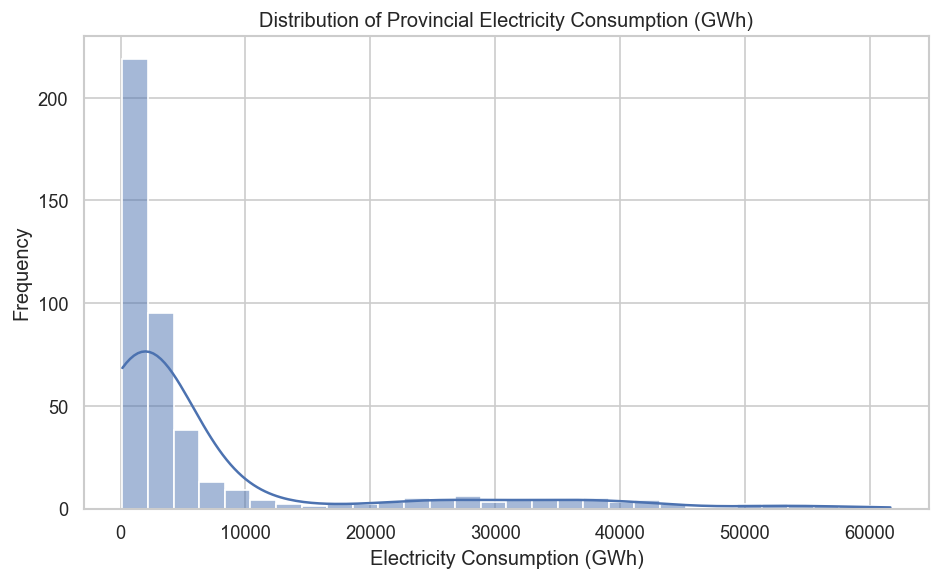

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_prov, x="listrik_gwh", bins=30, kde=True)
plt.title("Distribution of Provincial Electricity Consumption (GWh)")
plt.xlabel("Electricity Consumption (GWh)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

> Distribusi bersifat **right-skewed**, menunjukkan adanya ketimpangan konsumsi listrik antar provinsi.

## 6. Log Transformation

Untuk mengurangi skewness dan menstabilkan varians, dilakukan transformasi log.

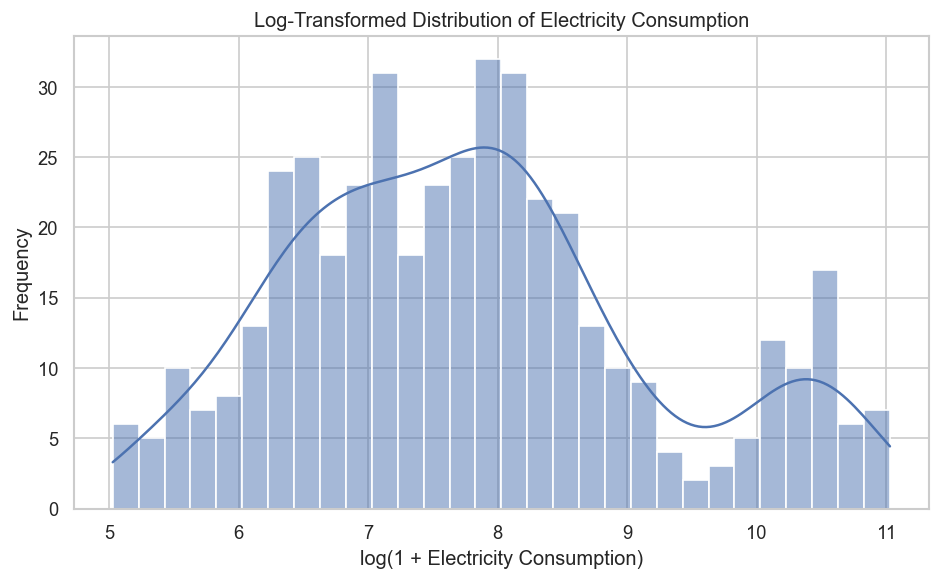

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df_prov["listrik_gwh"]), bins=30, kde=True)
plt.title("Log-Transformed Distribution of Electricity Consumption")
plt.xlabel("log(1 + Electricity Consumption)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

> Transformasi log digunakan untuk mengurangi skewness pada distribusi konsumsi listrik dan akan digunakan sebagai fitur dalam proses clustering untuk menstabilkan skala data.

## 7. Top 10 Provinces by Electricity Consumption

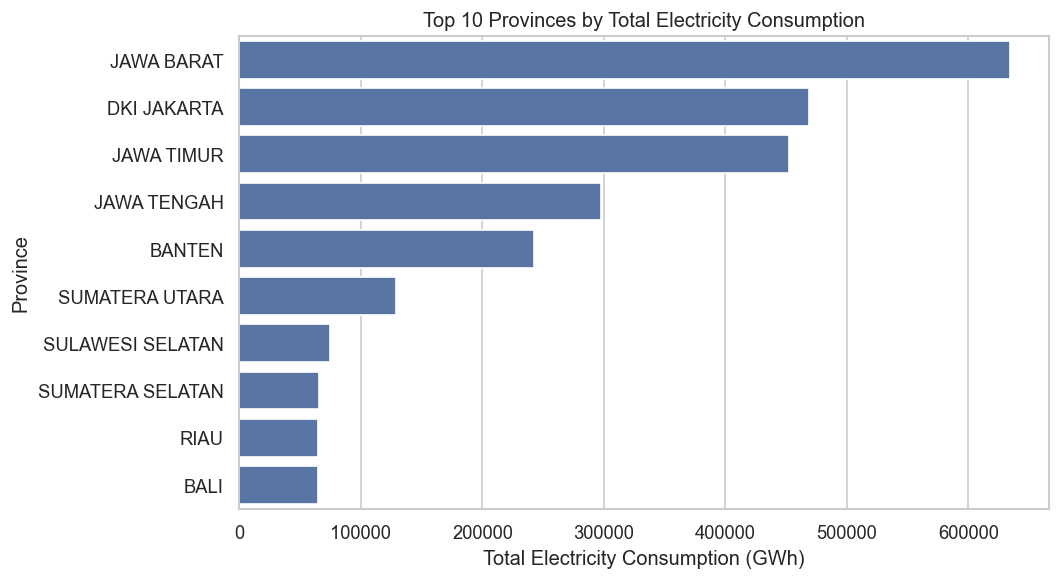

In [9]:
top_provinces = (
    df_prov
    .groupby("provinsi", as_index=False)["listrik_gwh"]
    .sum()
    .sort_values("listrik_gwh", ascending=False)
    .head(10)
)

plt.figure(figsize=(9,5))
sns.barplot(
    data=top_provinces,
    x="listrik_gwh",
    y="provinsi",
    order=top_provinces.sort_values("listrik_gwh", ascending=False)["provinsi"]
)
plt.title("Top 10 Provinces by Total Electricity Consumption")
plt.xlabel("Total Electricity Consumption (GWh)")
plt.ylabel("Province")
plt.tight_layout()
plt.show()

**Insight**

1. **Pulau Jawa mendominasi konsumsi listrik**, dengan lima provinsi teratas yaitu Jawa Barat, DKI Jakarta, Jawa Timur, Jawa Tengah, dan Banten.

2. **Jawa Barat memiliki konsumsi listrik tertinggi** dibanding provinsi lainnya selama periode analisis.

3. **Provinsi di luar Jawa memiliki konsumsi listrik relatif lebih rendah**, yang menunjukkan adanya perbedaan tingkat konsumsi listrik antar wilayah di Indonesia.

## 8. National Electricity Consumption Trend

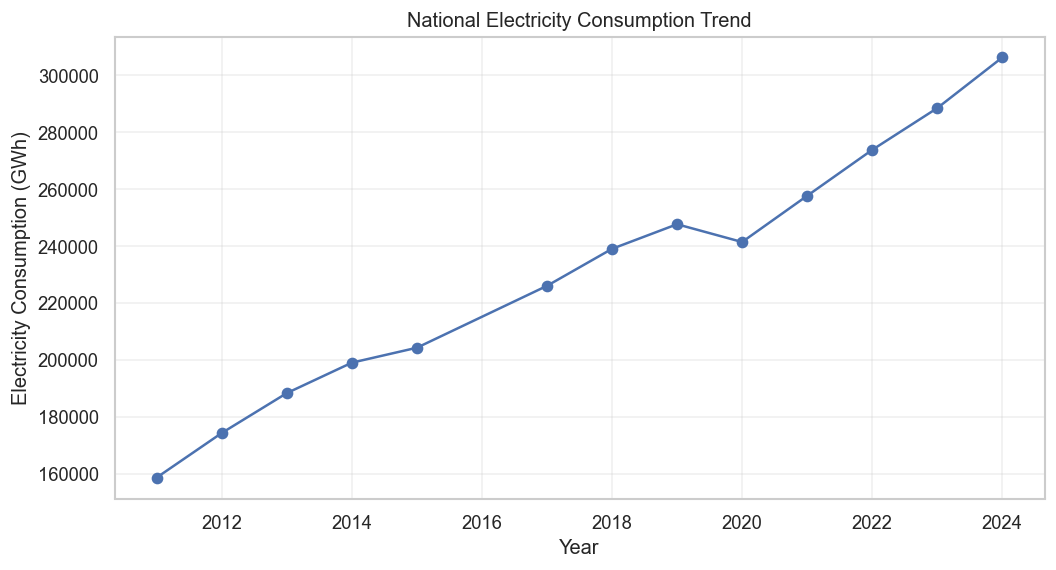

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df_nasional["tahun"], df_nasional["listrik_gwh"], marker="o")
plt.title("National Electricity Consumption Trend")
plt.xlabel("Year")
plt.ylabel("Electricity Consumption (GWh)")
plt.grid(alpha=0.3)
plt.show()

**Insight**

1. **Konsumsi listrik nasional menunjukkan tren meningkat** dari tahun 2011 hingga 2024, yang menandakan kebutuhan energi yang terus bertambah.

2. **Terjadi sedikit penurunan pada tahun 2020**, kemungkinan dipengaruhi oleh perlambatan aktivitas ekonomi.

3. **Setelah 2020 konsumsi listrik kembali meningkat secara konsisten** dan mencapai nilai tertinggi pada tahun 2024.

> Catatan: Perlu diperhatikan bahwa tidak terdapat data tahun 2016, sehingga perubahan antara 2015 dan 2017 merupakan lompatan dua tahun dan tidak merepresentasikan perubahan tahunan secara langsung.


## 9. Year-over-Year Growth Analysis


In [11]:
df_nasional = df_nasional.sort_values("tahun")

df_nasional["yoy_growth"] = df_nasional["listrik_gwh"].pct_change() * 100

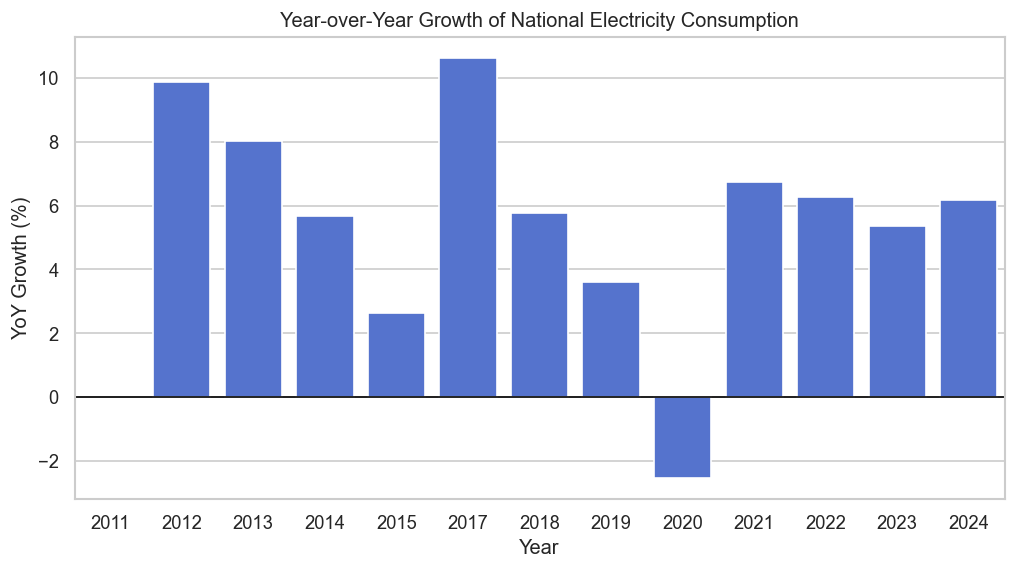

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(data=df_nasional, x="tahun", y="yoy_growth", color="royalblue")

plt.axhline(0, color="black", linewidth=1)
plt.title("Year-over-Year Growth of National Electricity Consumption")
plt.xlabel("Year")
plt.ylabel("YoY Growth (%)")

plt.show()


**Insight**

1. **Pertumbuhan konsumsi listrik nasional umumnya positif**, menunjukkan permintaan listrik yang terus meningkat hampir setiap tahun.

2. **Tahun 2017 menunjukkan lonjakan pertumbuhan yang relatif tinggi**, namun nilai ini berpotensi terdistorsi karena dihitung dari periode dua tahun (2015–2017), akibat tidak tersedianya data tahun 2016.

3. **Tahun 2020 mengalami pertumbuhan negatif**, yang kemungkinan disebabkan oleh penurunan aktivitas ekonomi.

4. **Setelah 2020, pertumbuhan kembali stabil di kisaran 5–7%**, menunjukkan pemulihan dan peningkatan kebutuhan listrik secara nasional.


## 10. Provincial Growth Analysis (CAGR)

In [13]:
df_growth = (
    df_prov
    .groupby(["provinsi", "tahun"], as_index=False)["listrik_gwh"]
    .sum()
)

def calculate_cagr(group):
    group = group.sort_values("tahun")
    start = group.iloc[0]["listrik_gwh"]
    end = group.iloc[-1]["listrik_gwh"]
    n_years = group["tahun"].nunique()

    if start <= 0 or n_years <= 1:
        return np.nan

    return (end / start) ** (1 / (n_years - 1)) - 1

cagr_provinsi = (
    df_growth
    .groupby("provinsi")
    .apply(calculate_cagr)
    .reset_index(name="cagr")
)

top_growth = (
    cagr_provinsi
    .dropna()
    .sort_values("cagr", ascending=False)
    .head(10)
)

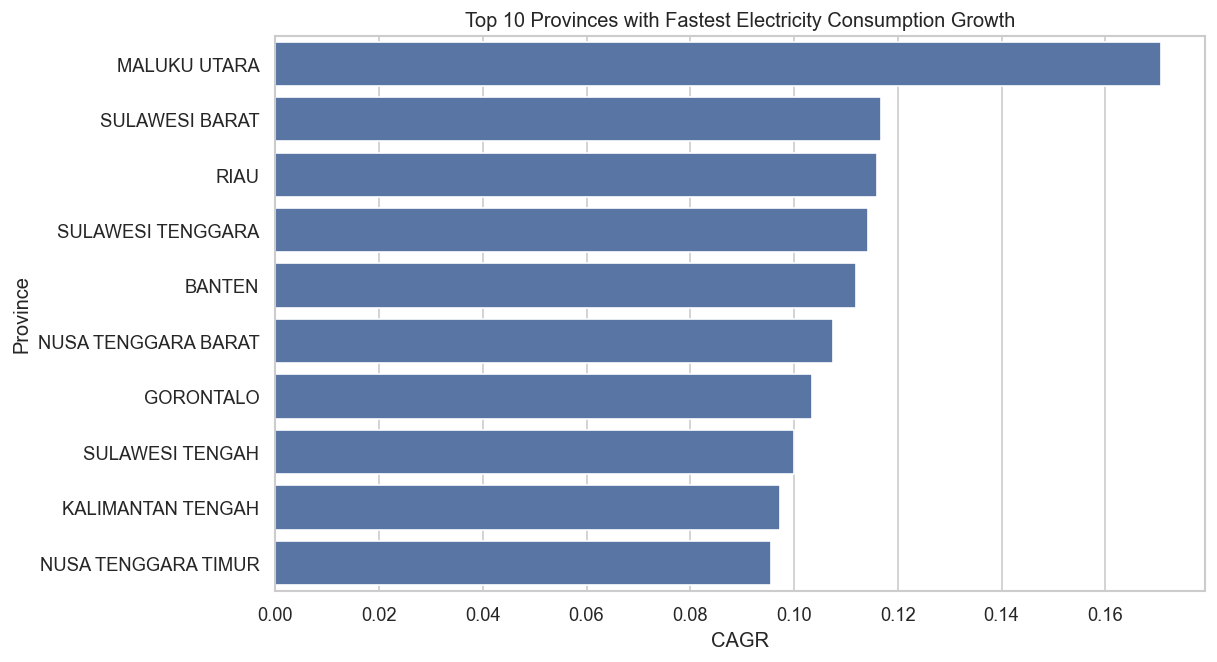

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_growth, x="cagr", y="provinsi")
plt.title("Top 10 Provinces with Fastest Electricity Consumption Growth")
plt.xlabel("CAGR")
plt.ylabel("Province")
plt.show()

**Insight**

1. **Maluku Utara memiliki pertumbuhan konsumsi listrik tercepat** dibanding provinsi lainnya selama periode analisis.

2. Beberapa provinsi di **Sulawesi (Sulawesi Barat, Sulawesi Tenggara, dan Sulawesi Tengah)** juga termasuk dalam wilayah dengan pertumbuhan konsumsi listrik yang tinggi.

3. **Sebagian besar provinsi dengan pertumbuhan tercepat berasal dari luar Pulau Jawa**, yang menunjukkan peningkatan permintaan listrik yang relatif lebih cepat di wilayah tersebut. Hal ini mengindikasikan potensi pertumbuhan aktivitas di luar Pulau Jawa.

## 11. Regional Comparison (Java vs Non-Java)

In [15]:
jawa = ["DKI JAKARTA","JAWA BARAT","JAWA TENGAH","DI YOGYAKARTA","JAWA TIMUR","BANTEN"]

df_prov["region"] = df_prov["provinsi"].apply(lambda x: "Jawa" if x in jawa else "Luar Jawa")

In [16]:
regional = (
    df_prov
    .groupby(["tahun","region"])["listrik_gwh"]
    .sum()
    .reset_index()
)

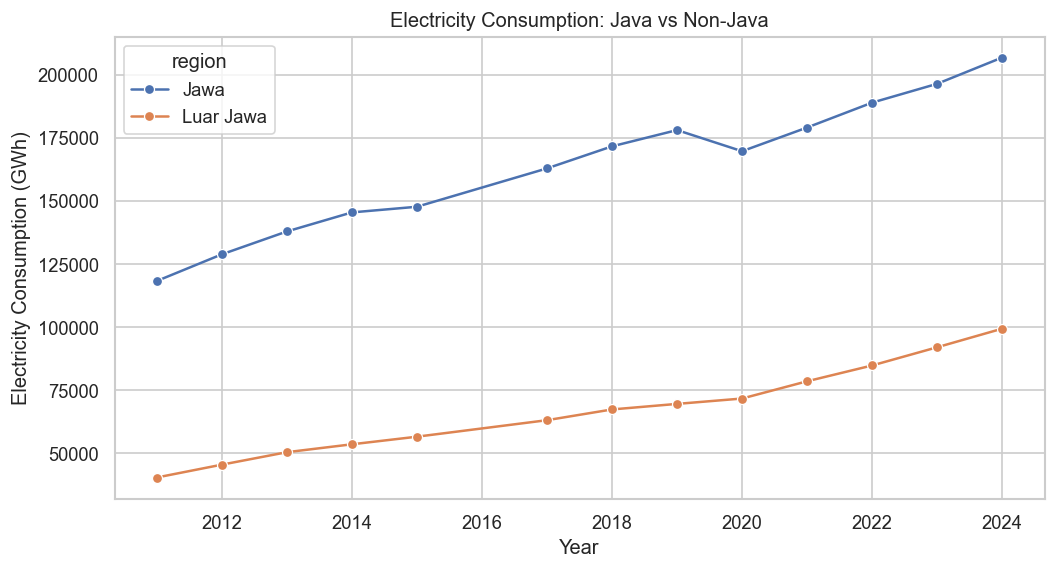

In [17]:
plt.figure(figsize=(10,5))
sns.lineplot(data=regional, x="tahun", y="listrik_gwh", hue="region", marker="o")

plt.title("Electricity Consumption: Java vs Non-Java")
plt.xlabel("Year")
plt.ylabel("Electricity Consumption (GWh)")

plt.show()


**Insight**

1. **Konsumsi listrik di Pulau Jawa secara konsisten lebih tinggi dibandingkan luar Jawa** sepanjang periode 2011–2024.

2. **Konsumsi listrik di kedua wilayah menunjukkan tren peningkatan dari tahun ke tahun**, menandakan meningkatnya kebutuhan listrik secara nasional.

3. **Meskipun lebih rendah, konsumsi listrik di luar Jawa juga terus meningkat**, yang menunjukkan pertumbuhan penggunaan listrik di wilayah tersebut.

## 12. Province Segmentation (K-Means)

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Gabungkan total konsumsi dan CAGR
cluster_df = (
    df_prov
    .groupby("provinsi", as_index=False)["listrik_gwh"]
    .sum()
    .merge(cagr_provinsi, on="provinsi", how="inner")
    .dropna()
)


# Log transform untuk konsumsi
cluster_df["log_listrik"] = np.log1p(cluster_df["listrik_gwh"])


features = cluster_df[["log_listrik", "cagr"]]


# Standardisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

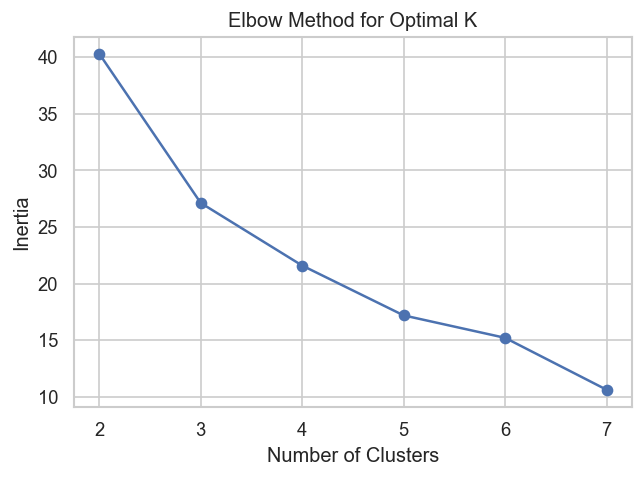

In [19]:
inertia = []
K = range(2, 8)


for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

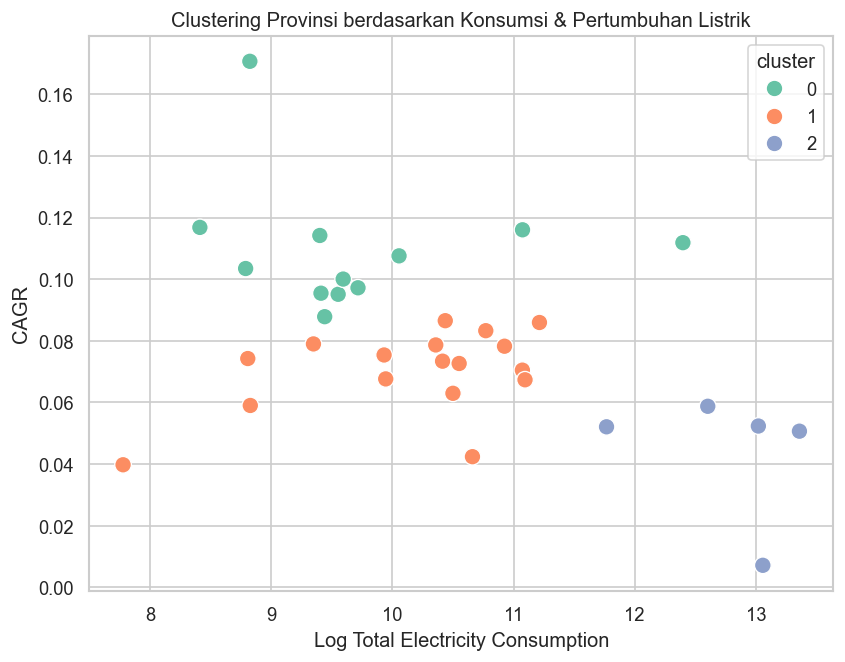

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=cluster_df,
    x="log_listrik",
    y="cagr",
    hue="cluster",
    palette="Set2",
    s=100
)
plt.title("Clustering Provinsi berdasarkan Konsumsi & Pertumbuhan Listrik")
plt.xlabel("Log Total Electricity Consumption")
plt.ylabel("CAGR")
plt.show()

In [22]:
cluster_summary = (
    cluster_df
    .groupby("cluster")
    .agg(
        avg_consumption_gwh=("listrik_gwh", "mean"),
        avg_cagr=("cagr", "mean"),
        n_provinces=("provinsi", "count")
    )
)


cluster_summary

,avg_consumption_gwh,avg_cagr,n_provinces
cluster,,,
0,35855.635000,0.109696,12
1,34854.927647,0.070422,17
2,396404.374000,0.044218,5


**Insight Clustering (Regional Segmentation)**

1. **Cluster 0 – High Growth Regions**

   Cluster ini menunjukkan **tingkat pertumbuhan konsumsi listrik tertinggi (~10.97%)**, dengan konsumsi yang masih berada pada level menengah (~35.855 GWh). Hal ini mengindikasikan bahwa wilayah dalam cluster ini mengalami **peningkatan permintaan listrik yang cepat**.

2. **Cluster 1 – Moderate Growth Regions**

   Cluster ini memiliki **tingkat konsumsi yang hampir setara dengan High Growth Regions (~34.855 GWh)**, namun dengan **pertumbuhan yang lebih moderat (~7.04%)**. Hal ini menunjukkan bahwa wilayah dalam cluster ini mengalami **pertumbuhan yang stabil namun tidak secepat High Growth Regions**.

3. **Cluster 2 – Mature High-Demand Regions**

   Cluster ini memiliki **rata-rata konsumsi listrik tertinggi (~396.404 GWh)** dibanding cluster lain, dengan **pertumbuhan relatif lebih rendah (~4.42%)**. Hal ini menunjukkan bahwa wilayah dalam cluster ini memiliki **permintaan listrik yang besar dan cenderung stabil**, sehingga laju pertumbuhannya lebih rendah dibanding cluster lainnya.

In [23]:
# Mapping cluster ke label yang lebih mudah dipahami
# Penamaan ulang cluster berdasarkan interpretasi final
cluster_labels = {
    0: "High Growth Regions",
    1: "Moderate Growth Regions",
    2: "Mature High-Demand Regions"
}


cluster_df["kategori"] = cluster_df["cluster"].map(cluster_labels)


# Tampilkan daftar provinsi per kategori
provinsi_per_kategori = (
    cluster_df
    .sort_values(["kategori", "listrik_gwh"], ascending=[True, False])
    [["provinsi", "kategori", "listrik_gwh", "cagr"]]
)


provinsi_per_kategori

,provinsi,kategori,listrik_gwh,cagr
2,BANTEN,High Growth Regions,242414.87,0.111859
25,RIAU,High Growth Regions,64496.36,0.116035
21,NUSA TENGGARA BARAT,High Growth Regions,23269.91,0.107581
13,KALIMANTAN TENGAH,High Growth Regions,16583.08,0.097218
28,SULAWESI TENGAH,High Growth Regions,14673.08,0.100047
16,KEP. BANGKA BELITUNG,High Growth Regions,14076.15,0.095112
23,PAPUA,High Growth Regions,12596.29,0.087841
22,NUSA TENGGARA TIMUR,High Growth Regions,12215.91,0.095460
29,SULAWESI TENGGARA,High Growth Regions,12099.45,0.114191
20,MALUKU UTARA,High Growth Regions,6790.42,0.170713


**Insight Regional Segmentation**

1. **High Growth Regions didominasi oleh provinsi di luar Pulau Jawa**
   Mayoritas provinsi dalam kategori ini berasal dari wilayah seperti Sumatera, Kalimantan, Sulawesi, dan Indonesia Timur. Beberapa bahkan memiliki **CAGR sangat tinggi (>10%)**, seperti Maluku Utara (~17.07%) dan Riau (~11.60%), meskipun tingkat konsumsi listriknya masih relatif lebih rendah dibanding provinsi besar.

2. **Mature High-Demand Regions terkonsentrasi pada provinsi dengan konsumsi terbesar**
   Kategori ini didominasi oleh provinsi seperti Jawa Barat, DKI Jakarta, Jawa Timur, dan Jawa Tengah dengan **total konsumsi listrik sangat tinggi (>290.000 GWh)**, namun dengan **pertumbuhan yang lebih rendah (~0.7%–5.8%)**, menunjukkan pola konsumsi yang lebih stabil.

3. **Moderate Growth Regions memiliki konsumsi menengah dengan pertumbuhan stabil**
   Provinsi dalam kategori ini memiliki **tingkat konsumsi dan pertumbuhan yang relatif seimbang**, dengan CAGR umumnya berada di kisaran **6%–8%**, seperti Bali, Lampung, dan Kalimantan Timur.

4. **Terdapat pola “catch-up growth” di luar Jawa**
   Wilayah dengan konsumsi lebih rendah cenderung memiliki **laju pertumbuhan lebih tinggi**, sementara wilayah dengan konsumsi tinggi menunjukkan **pertumbuhan yang lebih stabil**, mengindikasikan adanya perbedaan dinamika perkembangan konsumsi listrik antar wilayah.